In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/cleaned_data.csv')

In [4]:
df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,...,improvement_surcharge,total_amount,trip_duration_mins,pickup_hour,pickup_day,pickup_month,speed_mph,fare_per_mile,time_of_day,tip_pct
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,...,0.3,17.05,18.05,19,Thursday,1,5.285319,7.547170,evening_rush,0.27
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,...,0.3,17.80,19.83,20,Saturday,1,9.984871,4.393939,off_peak,0.14
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,...,0.3,10.80,10.05,20,Saturday,1,10.746269,5.277778,off_peak,0.00
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,...,0.3,4.80,1.87,20,Saturday,1,16.042781,7.000000,off_peak,0.00
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,...,0.3,16.30,19.32,20,Saturday,1,9.316770,5.000000,off_peak,0.00


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = df[df['trip_duration_mins'] > 0.5]
df = df[df['trip_distance'] > 0.1]
df['speed_mph'] = df['trip_distance']/(df['trip_duration_mins']/60)
df['fare_per_mile'] = df['fare_amount']/df['trip_distance']
df['tip_pct'] = (df['tip_amount']/df['fare_amount']*100).round(2)
df = df[df['speed_mph'] < 100]
df = df[df['fare_per_mile'] > 0]

print("shape:", df.shape)


shape: (99061, 27)


#Fare distribution


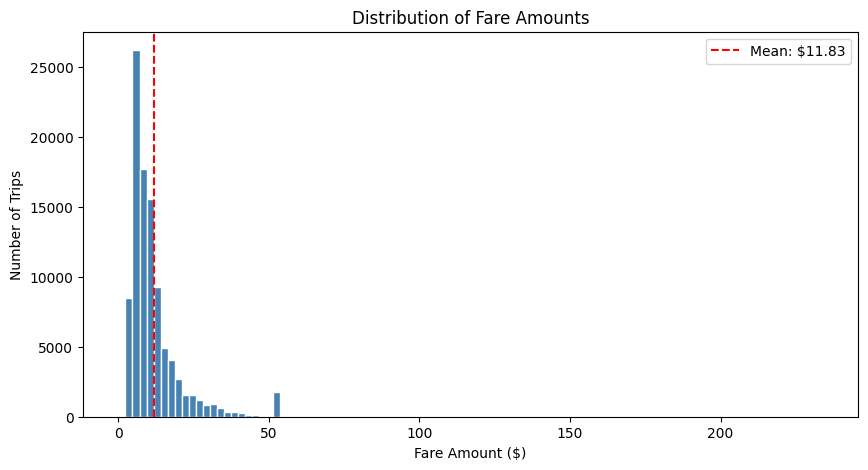

In [12]:
plt.figure(figsize=(10,5))
plt.hist(df['fare_amount'], bins=100, color='steelblue', edgecolor='white')
plt.title('Distribution of Fare Amounts')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Number of Trips')
plt.axvline(df['fare_amount'].mean(), color='red', linestyle='--', label=f"Mean: ${df['fare_amount'].mean():.2f}")
plt.legend()
plt.show()

In [13]:
print("Fares above $100:", len(df[df['fare_amount'] > 100]))
print("Fares above $50:", len(df[df['fare_amount'] > 50]))
print("Fares above $25:", len(df[df['fare_amount'] > 25]))

Fares above $100: 36
Fares above $50: 2134
Fares above $25: 7421


Insight
- Right/postively skeewed
- Most trips costs between 5-20
- A small number of very high fares 100+
- In dbt the fares above $100 will be flagged as a separate segment for business review

#Hourly Ride Volume

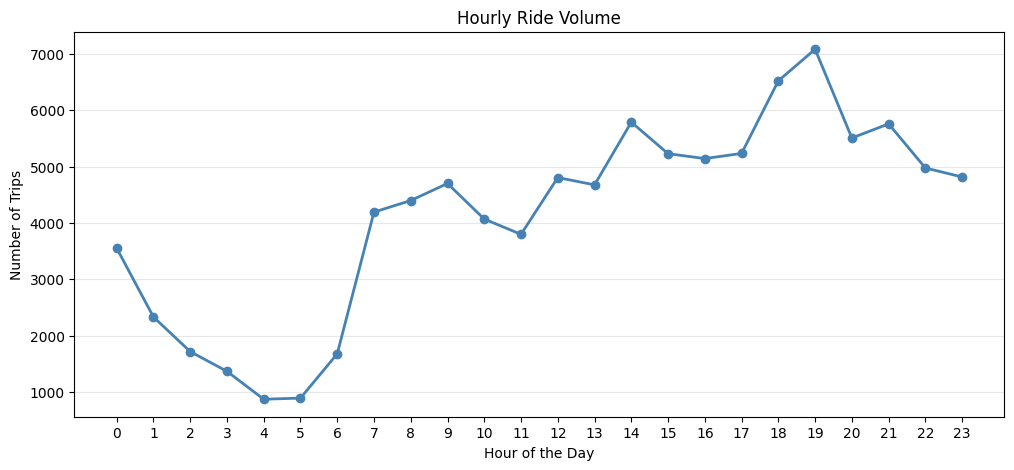

In [15]:
hourly = df.groupby('pickup_hour').size()
plt.figure(figsize=(12,5))
plt.plot(hourly.index, hourly.values, color='steelblue', linewidth=2, marker='o')
plt.title('Hourly Ride Volume')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0,24))
plt.grid(axis='y', alpha=0.3)
plt.show()

#Average Speed by time of day

In [16]:
speed_by_time = df.groupby('time_of_day')['speed_mph'].mean().round(2)

<Figure size 800x500 with 0 Axes>

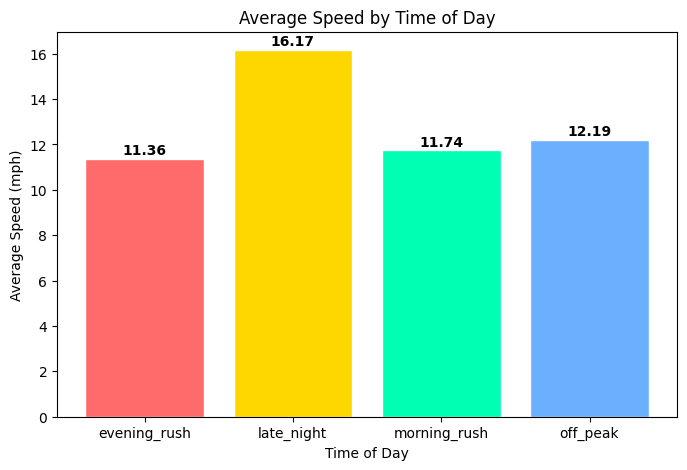

In [18]:
plt.figure(figsize=(8,5))

plt.figure(figsize=(8,5))
colors = ['#FF6B6B','#FFD700','#00FFB2','#6BB0FF']
plt.bar(speed_by_time.index, speed_by_time.values, color=colors, edgecolor='white')
plt.title('Average Speed by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Speed (mph)')
for i, v in enumerate(speed_by_time.values):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')
plt.show()

#Tip % by day of the week


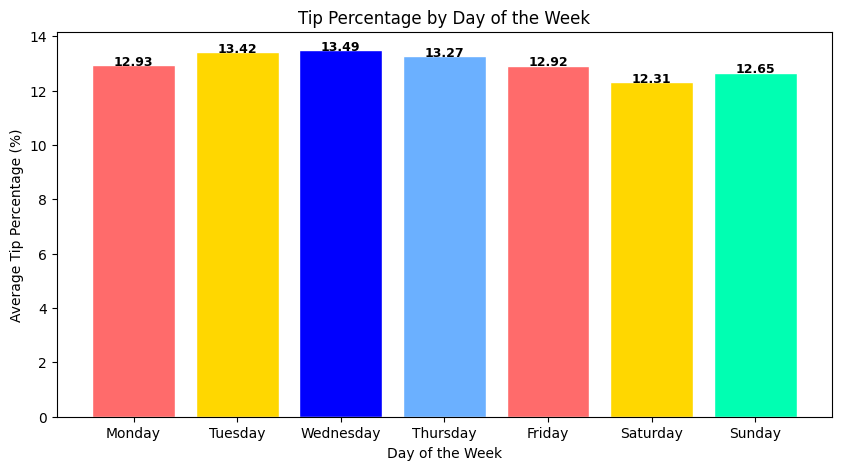

In [20]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
tip_by_day = df.groupby('pickup_day')['tip_pct'].mean().reindex(day_order).round(2)

plt.figure(figsize=(10,5))
colors = ['#FF6B6B','#FFD700','#00FF','#6BB0FF', '#FF6B6B','#FFD700','#00FFB2']
plt.bar(tip_by_day.index, tip_by_day.values, color=colors, edgecolor='white')
plt.title('Tip Percentage by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Tip Percentage (%)')
for i, v in enumerate(tip_by_day.values):
    plt.text(i, v + 0.001, str(v), ha='center', fontsize=9, fontweight='bold')
plt.show()

#Correlation Heatmap

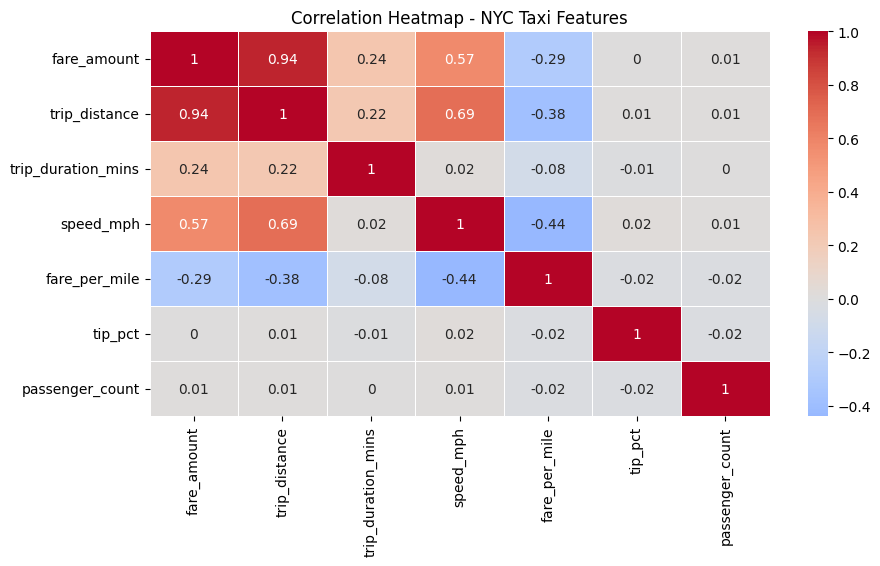

In [21]:
plt.figure(figsize=(10,5))
cols = ['fare_amount', 'trip_distance', 'trip_duration_mins', 'speed_mph', 'fare_per_mile', 'tip_pct', 'passenger_count']
sns.heatmap(df[cols].corr().round(2), annot=True, cmap='coolwarm', center = 0, linewidths=0.5)
plt.title('Correlation Heatmap - NYC Taxi Features')
plt.show()

## Day 04 — NYC Taxi Data: Visualization & Insights Summary

### Dataset
- 99,061 clean trips from NYC Yellow Taxi, January 2015
- 27 features after cleaning and feature engineering

### Key Findings

**Fare Distribution**
- Fare amounts are right-skewed — majority of trips cost between $5–$20
- Mean fare is pulled rightward by a small number of high-value trips ($50–$200)
- Classic pricing distribution seen across most transportation datasets

**Demand Patterns**
- Peak demand: 7pm (19th hour) — evening rush hour, office exits, dinner trips
- Lowest demand: 4am — city at rest, minimal movement
- Clear business implication: driver allocation should mirror this curve

**Speed vs Time of Day**
- Late night is fastest — open roads, minimal traffic
- Morning and evening rush are slowest — confirmed by data
- Average NYC taxi speed: 12.4 mph — reflects one of the world's most congested cities

**Tipping Behavior**
- Weekdays tip more than weekends (Wednesday highest at 13.49%, Saturday lowest at 12.31%)
- Likely driven by business/corporate riders on weekdays vs leisure tourists on weekends
- Tip percentage is nearly uncorrelated with fare amount, distance, or passenger count
- People tip on habit, not trip characteristics

**Correlation Analysis**
- Strongest relationship: fare ↔ distance (0.94) — meters run on distance, expected
- Efficiency insight: longer trips are cheaper per mile (highway effect)
- Passenger count has zero correlation with any metric — group size doesn't affect behavior
- Tipping is completely independent of all measured variables

### AE Connection
Every transformation and insight here maps directly to dbt model layers:
- Null/duplicate checks → dbt tests (not_null, unique)
- Bad data removal → staging model filters
- Feature engineering → intermediate model columns
- Group by insights → mart model aggregati